# Feature Engineering — Home Credit Default Risk

This notebook engineers domain-informed features on top of the cleaned dataset produced by `01_eda.ipynb`.  
Features are grouped into three families:
1. **Credit-risk domain ratios** — capture affordability and exposure
2. **External score aggregates** — distil the three credit bureau scores
3. **Flag aggregates** — compress sparse binary columns into dense signals

Each section ends with a correlation check against `TARGET` and a null audit.

In [9]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

DATA_PATH = '../data/raw/application_train.csv'


---
## 1. Load & Prepare Data

We re-apply the same cleaning pipeline from `01_eda.ipynb` so this notebook is fully self-contained and reproducible without needing to run the EDA notebook first.

Steps (mirrors EDA sections 3a → 3c):
- Drop columns with >50% missing (except `EXT_SOURCE_1`)
- Add missingness flags for columns >20% missing
- Impute numerical → median, categorical → mode
- Convert `DAYS_BIRTH` → `AGE_YEARS`, handle `DAYS_EMPLOYED` anomaly → `YEARS_EMPLOYED`

In [10]:
df = pd.read_csv(DATA_PATH)
print(f'Raw shape: {df.shape[0]:,} x {df.shape[1]}')

# -- 3a: drop >50% missing columns (keep EXT_SOURCE_1) --
missing_pct = df.isnull().mean() * 100
cols_to_drop = [c for c in df.columns if missing_pct[c] > 50 and c != 'EXT_SOURCE_1']
df = df.drop(columns=cols_to_drop)

df['EXT_SOURCE_1_missing'] = df['EXT_SOURCE_1'].isnull().astype('int8')
df['EXT_SOURCE_1'] = df['EXT_SOURCE_1'].fillna(df['EXT_SOURCE_1'].median())

# -- 3b: flags + imputation for remaining missing --
missing_pct = df.isnull().mean() * 100
EXCLUDE = {'SK_ID_CURR', 'TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_1_missing'}

for col in df.select_dtypes(include='number').columns:
    if col not in EXCLUDE and missing_pct[col] > 0:
        if missing_pct[col] > 20:
            df[col + '_missing'] = df[col].isnull().astype('int8')
        df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include='object').columns:
    if col not in EXCLUDE and missing_pct[col] > 0:
        if missing_pct[col] > 20:
            df[col + '_missing'] = df[col].isnull().astype('int8')
        df[col] = df[col].fillna(df[col].mode()[0])

# -- 3c: DAYS_BIRTH -> AGE_YEARS --
df['AGE_YEARS'] = (df['DAYS_BIRTH'].abs() / 365.25).round(2)
df = df.drop(columns=['DAYS_BIRTH'])

# -- 3c: DAYS_EMPLOYED -> YEARS_EMPLOYED --
ANOMALY = 365243
df['DAYS_EMPLOYED_anomaly'] = (df['DAYS_EMPLOYED'] == ANOMALY).astype('int8')
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(ANOMALY, float('nan'))
df['YEARS_EMPLOYED'] = (df['DAYS_EMPLOYED'].abs() / 365.25).round(2).fillna(0)
df = df.drop(columns=['DAYS_EMPLOYED'])

print(f'Cleaned shape : {df.shape[0]:,} x {df.shape[1]}')
print(f'Remaining nulls: {df.isnull().sum().sum()}')


Raw shape: 307,511 x 122
Cleaned shape : 307,511 x 93
Remaining nulls: 0


---
## 2. Credit-Risk Domain Features

These ratios encode **affordability and exposure** — the core questions a credit officer asks:

| Feature | Formula | What it captures |
|---|---|---|
| `CREDIT_INCOME_RATIO` | `AMT_CREDIT / AMT_INCOME_TOTAL` | How many years of income does the loan represent? Higher = more leveraged |
| `ANNUITY_INCOME_RATIO` | `AMT_ANNUITY / AMT_INCOME_TOTAL` | What share of income goes to repayment? Classic debt-service ratio |
| `CREDIT_TERM` | `AMT_CREDIT / AMT_ANNUITY` | Implied loan term in months |
| `EMPLOYED_LIFE_RATIO` | `YEARS_EMPLOYED / AGE_YEARS` | Fraction of life spent employed — stability proxy |
| `INCOME_PER_PERSON` | `AMT_INCOME_TOTAL / CNT_FAM_MEMBERS` | Household income per head — affordability adjusted for dependants |

In [11]:
df['CREDIT_INCOME_RATIO']  = df['AMT_CREDIT']   / df['AMT_INCOME_TOTAL']
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY']   / df['AMT_INCOME_TOTAL']
df['CREDIT_TERM']          = df['AMT_CREDIT']    / df['AMT_ANNUITY']
df['EMPLOYED_LIFE_RATIO']  = df['YEARS_EMPLOYED'] / df['AGE_YEARS']
df['INCOME_PER_PERSON']    = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']

domain_feats = [
    'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM',
    'EMPLOYED_LIFE_RATIO', 'INCOME_PER_PERSON',
]
print('--- Nulls introduced ---')
print(df[domain_feats].isnull().sum().to_string())
print('--- Correlations with TARGET ---')
print(df[domain_feats + ['TARGET']].corr()['TARGET'].drop('TARGET').round(4).to_string())
df[domain_feats].describe().T.round(3)


--- Nulls introduced ---
CREDIT_INCOME_RATIO     0
ANNUITY_INCOME_RATIO    0
CREDIT_TERM             0
EMPLOYED_LIFE_RATIO     0
INCOME_PER_PERSON       0
--- Correlations with TARGET ---
CREDIT_INCOME_RATIO    -0.0077
ANNUITY_INCOME_RATIO    0.0143
CREDIT_TERM            -0.0321
EMPLOYED_LIFE_RATIO    -0.0363
INCOME_PER_PERSON      -0.0066


,count,mean,std,min,25%,50%,75%,max
CREDIT_INCOME_RATIO,307511.0,3.958,2.690,0.005,2.019,3.265,5.160,8.473700e+01
ANNUITY_INCOME_RATIO,307511.0,0.181,0.095,0.000,0.115,0.163,0.229,1.876000e+00
CREDIT_TERM,307511.0,21.612,7.824,6.325,15.614,20.000,27.100,5.956000e+01
EMPLOYED_LIFE_RATIO,307511.0,0.129,0.135,0.000,0.022,0.089,0.191,7.290000e-01
INCOME_PER_PERSON,307511.0,93106.335,101373.314,2812.500,47250.000,75000.000,112500.000,3.900000e+07


**Null handling for domain features:**

- `CREDIT_TERM` and `ANNUITY_INCOME_RATIO` can be `NaN` if `AMT_ANNUITY` is 0 or missing — we'll fill with the column median (rare edge case).
- `EMPLOYED_LIFE_RATIO` can be `NaN` if `AGE_YEARS` is 0 (impossible in practice) or produce very large values for young applicants with many employment years — we clip to [0, 1] since a ratio above 1 is a data artefact.
- `INCOME_PER_PERSON` can be `NaN` if `CNT_FAM_MEMBERS` is 0 — fill with `AMT_INCOME_TOTAL`.

In [12]:
# Clip EMPLOYED_LIFE_RATIO to [0, 1] and fill residual NaNs with median
df['EMPLOYED_LIFE_RATIO'] = df['EMPLOYED_LIFE_RATIO'].clip(0, 1)

# Fill NaN in INCOME_PER_PERSON with AMT_INCOME_TOTAL (CNT_FAM_MEMBERS == 0 edge case)
mask = df['INCOME_PER_PERSON'].isnull()
df.loc[mask, 'INCOME_PER_PERSON'] = df.loc[mask, 'AMT_INCOME_TOTAL']

# Median fill for any remaining NaNs in domain features
for col in domain_feats:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

print('Nulls after fix:')
print(df[domain_feats].isnull().sum().to_string())


Nulls after fix:
CREDIT_INCOME_RATIO     0
ANNUITY_INCOME_RATIO    0
CREDIT_TERM             0
EMPLOYED_LIFE_RATIO     0
INCOME_PER_PERSON       0


---
## 3. External Score Aggregates

`EXT_SOURCE_1/2/3` are the strongest individual predictors in the dataset. Aggregating them into composite scores can capture cross-source signal:

| Feature | Formula | Rationale |
|---|---|---|
| `EXT_SOURCE_MEAN` | `mean(S1, S2, S3)` | Balanced average — robust to one noisy source |
| `EXT_SOURCE_MIN` | `min(S1, S2, S3)` | Worst score — lenders often care about the floor |
| `EXT_SOURCE_WEIGHTED` | `(S1·1 + S2·2 + S3·3) / 6` | Downweights S1 (highest missingness), upweights S3 |

In [13]:
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

df['EXT_SOURCE_MEAN']     = df[ext_cols].mean(axis=1)
df['EXT_SOURCE_MIN']      = df[ext_cols].min(axis=1)
df['EXT_SOURCE_WEIGHTED'] = (
    df['EXT_SOURCE_1'] * 1 +
    df['EXT_SOURCE_2'] * 2 +
    df['EXT_SOURCE_3'] * 3
) / 6

ext_feats = ['EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN', 'EXT_SOURCE_WEIGHTED']
print('--- Nulls introduced ---')
print(df[ext_feats].isnull().sum().to_string())
print('--- Correlations with TARGET ---')
print(df[ext_feats + ['TARGET']].corr()['TARGET'].drop('TARGET').round(4).to_string())
df[ext_feats].describe().T.round(3)


--- Nulls introduced ---
EXT_SOURCE_MEAN        0
EXT_SOURCE_MIN         0
EXT_SOURCE_WEIGHTED    0
--- Correlations with TARGET ---
EXT_SOURCE_MEAN       -0.2208
EXT_SOURCE_MIN        -0.1928
EXT_SOURCE_WEIGHTED   -0.2199


,count,mean,std,min,25%,50%,75%,max
EXT_SOURCE_MEAN,307511.0,0.512,0.108,0.024,0.442,0.522,0.588,0.853
EXT_SOURCE_MIN,307511.0,0.372,0.155,0.000,0.254,0.403,0.506,0.807
EXT_SOURCE_WEIGHTED,307511.0,0.513,0.119,0.025,0.437,0.526,0.597,0.853


---
## 4. Flag Aggregates

The dataset contains many sparse binary columns. Summing them reduces dimensionality and can expose a signal that no individual flag carries alone:

| Feature | Formula | Rationale |
|---|---|---|
| `DOCUMENT_FLAGS_SUM` | `sum(FLAG_DOCUMENT_*)` | How many documents did the applicant provide? More docs may indicate a more thorough application or a riskier profile |
| `SOCIAL_CIRCLE_DEFAULT_RATE` | `DEF_30_CNT / OBS_30_CNT` | What fraction of the applicant's social circle defaulted? Peer-group risk signal |

In [14]:
# DOCUMENT_FLAGS_SUM
doc_cols = [c for c in df.columns if c.startswith('FLAG_DOCUMENT_')]
df['DOCUMENT_FLAGS_SUM'] = df[doc_cols].sum(axis=1)
print(f'Summed {len(doc_cols)} FLAG_DOCUMENT_* columns')

# SOCIAL_CIRCLE_DEFAULT_RATE
# Guard against division by zero: OBS_30 == 0 means no observed neighbours -> set rate to 0
obs = df['OBS_30_CNT_SOCIAL_CIRCLE'].replace(0, float('nan'))
df['SOCIAL_CIRCLE_DEFAULT_RATE'] = (df['DEF_30_CNT_SOCIAL_CIRCLE'] / obs).fillna(0)

flag_feats = ['DOCUMENT_FLAGS_SUM', 'SOCIAL_CIRCLE_DEFAULT_RATE']
print('--- Nulls introduced ---')
print(df[flag_feats].isnull().sum().to_string())
print('--- Correlations with TARGET ---')
print(df[flag_feats + ['TARGET']].corr()['TARGET'].drop('TARGET').round(4).to_string())
df[flag_feats].describe().T.round(3)


Summed 20 FLAG_DOCUMENT_* columns
--- Nulls introduced ---
DOCUMENT_FLAGS_SUM            0
SOCIAL_CIRCLE_DEFAULT_RATE    0
--- Correlations with TARGET ---
DOCUMENT_FLAGS_SUM            0.0172
SOCIAL_CIRCLE_DEFAULT_RATE    0.0301


,count,mean,std,min,25%,50%,75%,max
DOCUMENT_FLAGS_SUM,307511.0,0.930,0.344,0.0,1.0,1.0,1.0,4.0
SOCIAL_CIRCLE_DEFAULT_RATE,307511.0,0.067,0.216,0.0,0.0,0.0,0.0,1.0


---
## 5. Summary

Full audit: list all engineered features, their correlations with `TARGET`, and any remaining nulls.

In [15]:
new_features = domain_feats + ext_feats + flag_feats

print(f'New features created: {len(new_features)}')
for f in new_features:
    print(f'  {f}')

print('\n--- Correlation with TARGET (sorted) ---')
corr_series = (
    df[new_features + ['TARGET']]
    .corr()['TARGET']
    .drop('TARGET')
    .abs()
    .sort_values(ascending=False)
)
print(corr_series.round(4).to_string())

print('\n--- Nulls in engineered features ---')
null_counts = df[new_features].isnull().sum()
print(null_counts[null_counts > 0].to_string() if null_counts.any() else 'None — all clean')

print(f'\nFinal shape: {df.shape[0]:,} rows  x  {df.shape[1]} columns')


New features created: 10
  CREDIT_INCOME_RATIO
  ANNUITY_INCOME_RATIO
  CREDIT_TERM
  EMPLOYED_LIFE_RATIO
  INCOME_PER_PERSON
  EXT_SOURCE_MEAN
  EXT_SOURCE_MIN
  EXT_SOURCE_WEIGHTED
  DOCUMENT_FLAGS_SUM
  SOCIAL_CIRCLE_DEFAULT_RATE

--- Correlation with TARGET (sorted) ---
EXT_SOURCE_MEAN               0.2208
EXT_SOURCE_WEIGHTED           0.2199
EXT_SOURCE_MIN                0.1928
EMPLOYED_LIFE_RATIO           0.0363
CREDIT_TERM                   0.0321
SOCIAL_CIRCLE_DEFAULT_RATE    0.0301
DOCUMENT_FLAGS_SUM            0.0172
ANNUITY_INCOME_RATIO          0.0143
CREDIT_INCOME_RATIO           0.0077
INCOME_PER_PERSON             0.0066

--- Nulls in engineered features ---
None — all clean

Final shape: 307,511 rows  x  103 columns


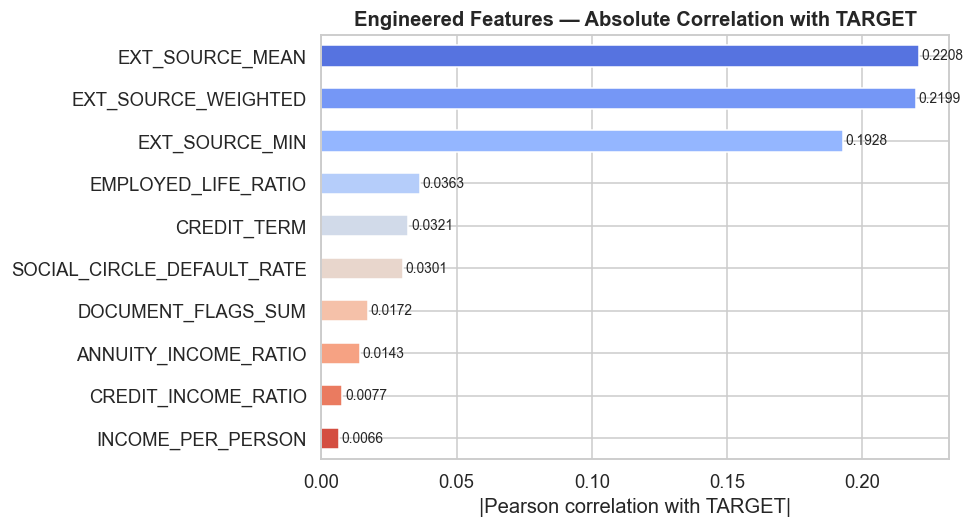

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette('coolwarm_r', len(corr_series))
corr_series.sort_values().plot.barh(ax=ax, color=colors, edgecolor='white')
ax.set_xlabel('|Pearson correlation with TARGET|')
ax.set_title('Engineered Features — Absolute Correlation with TARGET', fontweight='bold')
for bar in ax.patches:
    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.4f}',
        va='center', fontsize=9
    )
plt.tight_layout()
plt.show()
